In [14]:
import matplotlib.pyplot as plt
from IPython.display import Audio
import numpy as np
from scipy.signal import lfilter, butter
from scipy.io.wavfile import read
from scipy.fft import rfft, rfftfreq
import random

In [2]:
!wget http://www.phys.unsw.edu.au/~jw/speech/heardNormalegg.wav

--2026-04-29 09:57:29--  http://www.phys.unsw.edu.au/~jw/speech/heardNormalegg.wav
Resolving www.phys.unsw.edu.au (www.phys.unsw.edu.au)... 129.94.162.94
Connecting to www.phys.unsw.edu.au (www.phys.unsw.edu.au)|129.94.162.94|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.phys.unsw.edu.au/~jw/speech/heardNormalegg.wav [following]
--2026-04-29 09:57:30--  https://www.phys.unsw.edu.au/~jw/speech/heardNormalegg.wav
Connecting to www.phys.unsw.edu.au (www.phys.unsw.edu.au)|129.94.162.94|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 356396 (348K) [application/octet-stream]
Saving to: ‘heardNormalegg.wav’

heardNormalegg.wav  100%[===================>] 348.04K   268KB/s    in 1.3s    

2026-04-29 09:57:32 (268 KB/s) - ‘heardNormalegg.wav’ saved [356396/356396]



In [3]:
fs_natural, src_natural = read("heardNormalegg.wav")
src_natural = src_natural[:, 1]

In [4]:
Audio(src_natural, rate=fs_natural)

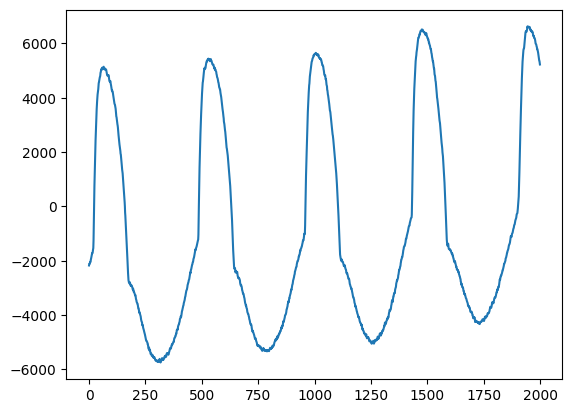

In [5]:
plt.plot(src_natural[2000:4000])
plt.show()

In [6]:
T = 1.0 / fs_natural
N = len(src_natural)

yf = rfft(src_natural * np.hamming(N))
xf = rfftfreq(N, T)

(0.0, 4000.0)

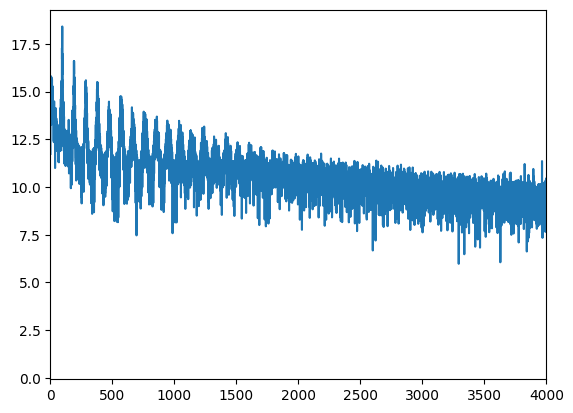

In [7]:
plt.plot(xf, np.log(np.abs(yf)))
plt.xlim(0, 4000)

In [11]:
def get_glottal_wave_period(T, fs):
  # функция, возвращающая один период глоттальной волны
  Tp = int(0.4 * T * fs)
  Tn = int(0.16 * T * fs)
  T_ = int(T * fs)

  fp = [3 * (t / Tp) ** 2 - 2 * (t / Tp) ** 3 for t in range(Tp)]
  fn = [1 - ((t - Tp) / Tn) ** 2 for t in range(Tp, Tp + Tn)]
  f0 = [0 for t in range(Tp + Tn, T_)]

  impulse = fp + fn + f0
  return np.array(impulse)

In [24]:
def get_glottal_wave(T, fs, duration, jitter=0.05, shimmer=0.05):
  # функция, возвращающая глоттальную волну нужной длительности
  glottal_wave = []

  period_num = int(duration / T)

  for i in range(period_num):
      T_new = T + T * jitter * random.random()
      new_impulse = get_glottal_wave_period(T_new, fs) * (1 + shimmer * random.random())
      glottal_wave.extend(new_impulse)

  return glottal_wave

In [9]:
fs = 44100
f0 = 100

In [25]:
src = get_glottal_wave(1/f0, fs, 2)

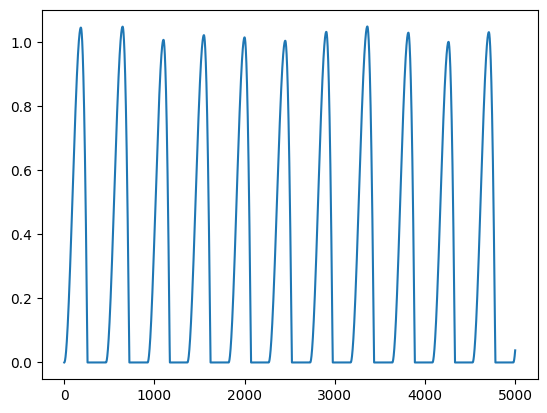

In [26]:
plt.plot(src[:5000])

In [27]:
Audio(src, rate=fs)

In [ ]:
def one_band_filter(sig, F, BW, fs=fs):
  # функция, возвращающая глоттальную волну, отфильтрованную одной формантой
  pass

In [ ]:
formant_freqs_a = [620,	1220,	2550,	3300,	4500]
bws_a = [80, 100, 140, 200, 250]

result_a = src
for freq, bw in zip(formant_freqs_a, bws_a):
  result_a = one_band_filter(result_a, freq, bw, fs)

In [ ]:
Audio(result_a, rate=fs)

In [ ]:
def plot_spectrum(sig, fs, xlim=10000, log=False):
  freqs = rfftfreq(len(sig), 1/fs)
  spectrum = np.log(np.abs(rfft(sig))) if log else np.abs(rfft(sig))
  plt.plot(freqs, spectrum)
  plt.grid()
  plt.xlim(0, xlim)

In [ ]:
plot_spectrum(result_a, fs, 3500, True)

In [ ]:
formants = {
    "a": {
      "freqs": [620,	1220,	2550,	3300,	4500],
      "bws": [80, 100, 140, 200, 250],
    },
    "e": {
      "freqs": [550, 2000, 2600, 3450, 4700],
      "bws": [50, 80, 100, 150, 200],
    },
    "i": {
      "freqs": [300, 2200, 3000, 3700, 5000],
      "bws": [60, 110, 130, 220, 270],
    },
    "o": {
      "freqs": [500, 800, 2500, 3200, 4300],
      "bws": [50, 80, 80, 150, 200],
    },
    "u": {
      "freqs": [300, 600, 2200, 3000, 4000],
      "bws": [50, 80, 100, 170, 220],
    },
    "y": {
      "freqs": [450, 1400, 2300, 3400, 4500],
      "bws": [70, 110, 120, 200, 250],
    },
}

In [ ]:
def filter_by_formants(formant_dict, src, fs):
  formant_freqs = formant_dict["freqs"]
  bws = formant_dict["bws"]

  result = src
  for freq, bw in zip(formant_freqs, bws):
    result = one_band_filter(result, freq, bw, fs)

  return result

In [ ]:
res_a = filter_by_formants(formants["a"], src, fs)
res_e = filter_by_formants(formants["e"], src, fs)
res_i = filter_by_formants(formants["i"], src, fs)
res_o = filter_by_formants(formants["o"], src, fs)
res_u = filter_by_formants(formants["u"], src, fs)
res_y = filter_by_formants(formants["y"], src, fs)

In [ ]:
Audio(res_u, rate=fs)

In [ ]:
plot_spectrum(res_u, fs, 4000, True)